# Notebook 05 — Transfer Learning

## Data-Driven Framework for Early Detection of Alzheimer's Disease Using MRI Brain Images

---

### What This Notebook Does
1. Train 3 pretrained models: **ResNet18**, **EfficientNet-B0**, **VGG16**
2. Use **two-stage fine-tuning** (head only -> then unfreeze last blocks)
3. Compare all models (+ baseline CNN from Notebook 04)
4. Select and save the best-performing model

### Hardware-Aware Model Selection
| Model | Params | VRAM (batch=32) | Notes |
|-------|--------|-----------------|-------|
| ResNet18 | 11.7M | ~2 GB | Fast, solid performance |
| EfficientNet-B0 | 5.3M | ~1.5 GB | Best accuracy/compute ratio |
| VGG16 | 138M | ~4 GB | Uses batch=16 to stay safe |

### Next Notebook
`06_model_evaluation.ipynb` — Evaluate the best model with confusion matrix and classification report.

## 1. Setup

In [1]:
import os
import json
import time
import copy
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image

sns.set_theme(style='whitegrid', font_scale=1.1)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM: 6.4 GB


In [2]:
# ============ Load config ============
PROCESSED_DIR = Path("processed")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

with open(PROCESSED_DIR / 'preprocessing_config.json', 'r') as f:
    config = json.load(f)

IMG_SIZE = config['img_size']
NUM_CLASSES = config['num_classes']
CLASS_NAMES = config['class_names']
IDX_TO_CLASS = {i: name for i, name in enumerate(CLASS_NAMES)}
IMAGENET_MEAN = config['imagenet_mean']
IMAGENET_STD = config['imagenet_std']
NUM_WORKERS = 0  # MUST be 0 on Windows + Jupyter to avoid hanging

print(f"Image size: {IMG_SIZE}, Classes: {NUM_CLASSES}")

Image size: 128, Classes: 4


## 2. Data Loading (reusable function)

In [3]:
class AlzheimerDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


def create_data_loaders(batch_size=32):
    """Create train and val DataLoaders with the given batch size."""
    train_transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=15),
        T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    val_transform = T.Compose([
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])

    train_df = pd.read_csv(PROCESSED_DIR / 'train_files.csv')
    val_df = pd.read_csv(PROCESSED_DIR / 'val_files.csv')

    train_paths, train_labels = train_df['path'].tolist(), train_df['label'].tolist()
    val_paths, val_labels = val_df['path'].tolist(), val_df['label'].tolist()

    train_dataset = AlzheimerDataset(train_paths, train_labels, transform=train_transform)
    val_dataset = AlzheimerDataset(val_paths, val_labels, transform=val_transform)

    # WeightedRandomSampler
    label_counts = Counter(train_labels)
    total = len(train_labels)
    cw = {idx: total / (NUM_CLASSES * cnt) for idx, cnt in label_counts.items()}
    sw = torch.DoubleTensor([cw[l] for l in train_labels])
    sampler = WeightedRandomSampler(sw, len(sw), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=True)
    
    return train_loader, val_loader, cw

print("Data loading function defined.")

Data loading function defined.


## 3. Generic Training Functions

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


def train_model(model, model_name, train_loader, val_loader, criterion,
                num_epochs=15, lr=1e-3, weight_decay=1e-4,
                early_patience=7, scheduler_patience=4):
    """Full training loop with early stopping. Returns history and best state."""
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                          lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=scheduler_patience, verbose=False)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
    best_val_acc = 0.0
    best_epoch = 0
    early_counter = 0
    best_state = None

    print(f"\n{'='*75}")
    print(f"Training: {model_name}")
    print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*75}")
    print(f"{'Ep':>3} | {'TrLoss':>7} {'TrAcc':>7} | {'VaLoss':>7} {'VaAcc':>7} | {'LR':>9} | Status")
    print("-" * 75)

    start = time.time()
    for epoch in range(1, num_epochs + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = validate(model, val_loader, criterion, device)
        cur_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(tl)
        history['train_acc'].append(ta)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        history['lr'].append(cur_lr)

        if va > best_val_acc:
            best_val_acc = va
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            early_counter = 0
            status = "BEST"
        else:
            early_counter += 1
            status = f"wait {early_counter}/{early_patience}"

        scheduler.step(vl)
        print(f"{epoch:>3} | {tl:>7.4f} {ta:>6.1%} | {vl:>7.4f} {va:>6.1%} | {cur_lr:>.2e} | {status}")

        if early_counter >= early_patience:
            print(f"Early stopping at epoch {epoch}")
            break

    elapsed = time.time() - start
    print(f"Done in {elapsed/60:.1f} min | Best: {best_val_acc:.2%} @ epoch {best_epoch}")
    return history, best_state, best_val_acc, best_epoch, elapsed

print("Training functions defined.")

Training functions defined.


## 4. Model Factory

This function creates any of our 3 pretrained models with the classification head replaced for 4 classes. All layers are initially **frozen** except the new head.

In [5]:
def create_model(model_name, num_classes=4, freeze_backbone=True):
    """
    Create a pretrained model with a new classification head.
    
    Args:
        model_name: 'resnet18', 'efficientnet_b0', or 'vgg16'
        num_classes: number of output classes
        freeze_backbone: if True, freeze all pretrained layers
    
    Returns:
        model on device, recommended batch size
    """
    if model_name == 'resnet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        # Replace final FC layer
        in_features = model.fc.in_features  # 512
        model.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
        batch_size = 32
        
    elif model_name == 'efficientnet_b0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.parameters():
                param.requires_grad = False
        # Replace classifier
        in_features = model.classifier[1].in_features  # 1280
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )
        batch_size = 32
        
    elif model_name == 'vgg16':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        if freeze_backbone:
            for param in model.features.parameters():
                param.requires_grad = False
        # Replace classifier (keep first layers, replace last)
        model.classifier[6] = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(4096, num_classes)
        )
        batch_size = 16  # VGG16 is heavy -- use smaller batch
        
    else:
        raise ValueError(f"Unknown model: {model_name}")
    
    model = model.to(device)
    
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{model_name}: {total:,} total params, {trainable:,} trainable")
    print(f"  Recommended batch size: {batch_size}")
    
    return model, batch_size


def unfreeze_last_blocks(model, model_name, num_blocks=2):
    """
    Unfreeze the last N blocks of the backbone for fine-tuning.
    """
    if model_name == 'resnet18':
        # ResNet18 has layer1, layer2, layer3, layer4
        layers = [model.layer3, model.layer4]
        for layer in layers[-num_blocks:]:
            for param in layer.parameters():
                param.requires_grad = True
                
    elif model_name == 'efficientnet_b0':
        # EfficientNet has features[0..8], unfreeze last blocks
        blocks = list(model.features.children())
        for block in blocks[-num_blocks:]:
            for param in block.parameters():
                param.requires_grad = True
                
    elif model_name == 'vgg16':
        # VGG16 features: unfreeze last few conv layers
        features = list(model.features.children())
        for layer in features[-6:]:  # Last 2 conv blocks
            if hasattr(layer, 'weight'):
                layer.weight.requires_grad = True
                if layer.bias is not None:
                    layer.bias.requires_grad = True
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  After unfreezing: {trainable:,} trainable params")


print("Model factory functions defined.")

Model factory functions defined.


## 5. Train All Models

### Strategy: Two-Stage Fine-Tuning
1. **Stage 1 (Head Only):** Freeze backbone, train only the new classification head for ~10 epochs. Uses higher learning rate.
2. **Stage 2 (Fine-Tune):** Unfreeze last 2 blocks of backbone, train end-to-end for ~10 more epochs. Uses lower learning rate.

This prevents the pretrained weights from being destroyed by large initial gradients.

In [8]:
# ============ Results storage ============
all_results = {}  # model_name -> {history, best_acc, time, ...}

# Loss weights
loss_weights = torch.FloatTensor(config['loss_weights']).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weights)

### 5.1 ResNet18

In [10]:
# Clear GPU memory before each model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Stage 1: Train head only
resnet_model, resnet_bs = create_model('resnet18', NUM_CLASSES, freeze_backbone=True)
train_loader, val_loader, _ = create_data_loaders(batch_size=resnet_bs)

print("\n--- Stage 1: Head only (frozen backbone) ---")
h1, s1, a1, e1, t1 = train_model(
    resnet_model, 'ResNet18 (Head)', train_loader, val_loader, criterion,
    num_epochs=10, lr=1e-3, early_patience=5
)

# Stage 2: Fine-tune last layers
print("\n--- Stage 2: Fine-tuning last blocks ---")
resnet_model.load_state_dict(s1)  # Start from best stage 1
unfreeze_last_blocks(resnet_model, 'resnet18', num_blocks=2)

h2, s2, a2, e2, t2 = train_model(
    resnet_model, 'ResNet18 (Fine-tune)', train_loader, val_loader, criterion,
    num_epochs=10, lr=1e-4, early_patience=5
)

# Merge histories
resnet_history = {k: h1[k] + h2[k] for k in h1}
resnet_best_acc = max(a1, a2)
resnet_best_state = s2 if a2 >= a1 else s1

all_results['ResNet18'] = {
    'history': resnet_history, 'best_acc': resnet_best_acc,
    'best_state': resnet_best_state, 'time': t1 + t2
}

# Save
torch.save({'model_name': 'resnet18', 'model_state_dict': resnet_best_state,
            'num_classes': NUM_CLASSES, 'img_size': IMG_SIZE, 'class_names': CLASS_NAMES,
            'best_val_acc': resnet_best_acc, 'history': resnet_history},
           MODELS_DIR / 'resnet18.pth')
print(f"\nResNet18 saved. Best val acc: {resnet_best_acc:.2%}")


resnet18: 11,178,564 total params, 2,052 trainable
  Recommended batch size: 32

--- Stage 1: Head only (frozen backbone) ---

Training: ResNet18 (Head)
Trainable params: 2,052
 Ep |  TrLoss   TrAcc |  VaLoss   VaAcc |        LR | Status
---------------------------------------------------------------------------


c:\Users\Karan Banerjee\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  1 |  0.6548  40.9% |  1.5191  12.3% | 1.00e-03 | BEST
  2 |  0.5726  45.6% |  1.2193  21.2% | 1.00e-03 | BEST
  3 |  0.5679  47.0% |  1.6103  14.4% | 1.00e-03 | wait 1/5
  4 |  0.5507  48.1% |  1.3698  18.4% | 1.00e-03 | wait 2/5
  5 |  0.5726  47.5% |  1.3831  17.8% | 1.00e-03 | wait 3/5
  6 |  0.5581  47.6% |  1.5718  13.1% | 1.00e-03 | wait 4/5
  7 |  0.5660  48.1% |  1.4317  17.0% | 1.00e-03 | wait 5/5
Early stopping at epoch 7
Done in 12.8 min | Best: 21.18% @ epoch 2

--- Stage 2: Fine-tuning last blocks ---
  After unfreezing: 10,495,492 trainable params

Training: ResNet18 (Fine-tune)
Trainable params: 10,495,492
 Ep |  TrLoss   TrAcc |  VaLoss   VaAcc |        LR | Status
---------------------------------------------------------------------------
  1 |  0.2003  70.0% |  0.3705  67.0% | 1.00e-04 | BEST
  2 |  0.0909  82.3% |  0.4139  69.7% | 1.00e-04 | BEST
  3 |  0.0662  86.3% |  0.1758  85.5% | 1.00e-04 | BEST
  4 |  0.0501  89.8% |  0.1758  85.0% | 1.00e-04 | wait 1/5
  5 

### 5.2 EfficientNet-B0

In [11]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
del resnet_model  # Free memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Stage 1: Head only
effnet_model, effnet_bs = create_model('efficientnet_b0', NUM_CLASSES, freeze_backbone=True)
train_loader, val_loader, _ = create_data_loaders(batch_size=effnet_bs)

print("\n--- Stage 1: Head only (frozen backbone) ---")
h1, s1, a1, e1, t1 = train_model(
    effnet_model, 'EfficientNet-B0 (Head)', train_loader, val_loader, criterion,
    num_epochs=10, lr=1e-3, early_patience=5
)

# Stage 2: Fine-tune
print("\n--- Stage 2: Fine-tuning last blocks ---")
effnet_model.load_state_dict(s1)
unfreeze_last_blocks(effnet_model, 'efficientnet_b0', num_blocks=3)

h2, s2, a2, e2, t2 = train_model(
    effnet_model, 'EfficientNet-B0 (Fine-tune)', train_loader, val_loader, criterion,
    num_epochs=10, lr=1e-4, early_patience=5
)

effnet_history = {k: h1[k] + h2[k] for k in h1}
effnet_best_acc = max(a1, a2)
effnet_best_state = s2 if a2 >= a1 else s1

all_results['EfficientNet-B0'] = {
    'history': effnet_history, 'best_acc': effnet_best_acc,
    'best_state': effnet_best_state, 'time': t1 + t2
}

torch.save({'model_name': 'efficientnet_b0', 'model_state_dict': effnet_best_state,
            'num_classes': NUM_CLASSES, 'img_size': IMG_SIZE, 'class_names': CLASS_NAMES,
            'best_val_acc': effnet_best_acc, 'history': effnet_history},
           MODELS_DIR / 'efficientnet_b0.pth')
print(f"\nEfficientNet-B0 saved. Best val acc: {effnet_best_acc:.2%}")


efficientnet_b0: 4,012,672 total params, 5,124 trainable
  Recommended batch size: 32

--- Stage 1: Head only (frozen backbone) ---

Training: EfficientNet-B0 (Head)
Trainable params: 5,124
 Ep |  TrLoss   TrAcc |  VaLoss   VaAcc |        LR | Status
---------------------------------------------------------------------------


c:\Users\Karan Banerjee\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  1 |  0.6347  41.8% |  1.5124  14.9% | 1.00e-03 | BEST
  2 |  0.5498  46.9% |  1.3921  20.6% | 1.00e-03 | BEST
  3 |  0.5360  48.8% |  1.3474  22.7% | 1.00e-03 | BEST
  4 |  0.5246  49.3% |  1.2672  25.3% | 1.00e-03 | BEST
  5 |  0.5347  49.3% |  1.3993  22.1% | 1.00e-03 | wait 1/5
  6 |  0.5303  50.1% |  1.3016  24.7% | 1.00e-03 | wait 2/5
  7 |  0.5249  50.5% |  1.3089  25.3% | 1.00e-03 | wait 3/5
  8 |  0.5250  49.9% |  1.2838  23.9% | 1.00e-03 | wait 4/5
  9 |  0.5168  50.6% |  1.2684  25.5% | 1.00e-03 | BEST
 10 |  0.5155  50.5% |  1.3271  24.7% | 5.00e-04 | wait 1/5
Done in 18.2 min | Best: 25.54% @ epoch 9

--- Stage 2: Fine-tuning last blocks ---
  After unfreezing: 3,160,864 trainable params

Training: EfficientNet-B0 (Fine-tune)
Trainable params: 3,160,864
 Ep |  TrLoss   TrAcc |  VaLoss   VaAcc |        LR | Status
---------------------------------------------------------------------------
  1 |  0.3513  58.5% |  0.8824  40.9% | 1.00e-04 | BEST
  2 |  0.2092  68.2% |  0.615

### 5.3 VGG16 (Optional -- Heavier Model)

VGG16 has 138M parameters. We use **batch_size=16** to fit in 6GB VRAM.

In [12]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
del effnet_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Stage 1: Head only
vgg_model, vgg_bs = create_model('vgg16', NUM_CLASSES, freeze_backbone=True)
train_loader, val_loader, _ = create_data_loaders(batch_size=vgg_bs)  # batch=16

print("\n--- Stage 1: Head only (frozen backbone) ---")
h1, s1, a1, e1, t1 = train_model(
    vgg_model, 'VGG16 (Head)', train_loader, val_loader, criterion,
    num_epochs=10, lr=1e-3, early_patience=5
)

# Stage 2: Fine-tune last conv blocks
print("\n--- Stage 2: Fine-tuning last blocks ---")
vgg_model.load_state_dict(s1)
unfreeze_last_blocks(vgg_model, 'vgg16', num_blocks=2)

h2, s2, a2, e2, t2 = train_model(
    vgg_model, 'VGG16 (Fine-tune)', train_loader, val_loader, criterion,
    num_epochs=10, lr=5e-5, early_patience=5
)

vgg_history = {k: h1[k] + h2[k] for k in h1}
vgg_best_acc = max(a1, a2)
vgg_best_state = s2 if a2 >= a1 else s1

all_results['VGG16'] = {
    'history': vgg_history, 'best_acc': vgg_best_acc,
    'best_state': vgg_best_state, 'time': t1 + t2
}

torch.save({'model_name': 'vgg16', 'model_state_dict': vgg_best_state,
            'num_classes': NUM_CLASSES, 'img_size': IMG_SIZE, 'class_names': CLASS_NAMES,
            'best_val_acc': vgg_best_acc, 'history': vgg_history},
           MODELS_DIR / 'vgg16.pth')
print(f"\nVGG16 saved. Best val acc: {vgg_best_acc:.2%}")

del vgg_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


vgg16: 134,276,932 total params, 119,562,244 trainable
  Recommended batch size: 16

--- Stage 1: Head only (frozen backbone) ---

Training: VGG16 (Head)
Trainable params: 119,562,244
 Ep |  TrLoss   TrAcc |  VaLoss   VaAcc |        LR | Status
---------------------------------------------------------------------------


c:\Users\Karan Banerjee\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  1 |  1.0562  39.6% |  2.0047   5.4% | 1.00e-03 | BEST
  2 |  0.6325  41.9% |  1.5770  10.2% | 1.00e-03 | BEST
  3 |  0.5769  43.0% |  1.4034  10.4% | 1.00e-03 | BEST
  4 |  0.5529  44.3% |  1.4136  10.7% | 1.00e-03 | BEST
  5 |  0.5746  45.2% |  1.2872  12.1% | 1.00e-03 | BEST
  6 |  0.5682  45.5% |  1.6971  10.6% | 1.00e-03 | wait 1/5
  7 |  0.5995  43.5% |  1.6851  10.8% | 1.00e-03 | wait 2/5
  8 |  0.6032  45.0% |  1.8361  10.2% | 1.00e-03 | wait 3/5
  9 |  0.5979  45.5% |  1.4833  10.5% | 1.00e-03 | wait 4/5
 10 |  0.5596  45.5% |  1.4241  10.6% | 1.00e-03 | wait 5/5
Early stopping at epoch 10
Done in 64.1 min | Best: 12.09% @ epoch 5

--- Stage 2: Fine-tuning last blocks ---
  After unfreezing: 124,281,860 trainable params

Training: VGG16 (Fine-tune)
Trainable params: 124,281,860
 Ep |  TrLoss   TrAcc |  VaLoss   VaAcc |        LR | Status
---------------------------------------------------------------------------
  1 |  0.3650  56.7% |  0.7214  34.5% | 5.00e-05 | BEST
  2 |  0

## 6. Compare All Models

Let's compare the transfer learning models against the baseline CNN from Notebook 04.

In [13]:
# Load baseline results from Notebook 04
baseline_ckpt = torch.load(MODELS_DIR / 'baseline_cnn.pth', map_location='cpu', weights_only=False)
all_results['Baseline CNN'] = {
    'history': baseline_ckpt['history'],
    'best_acc': baseline_ckpt['best_val_acc'],
    'time': 0  # unknown from checkpoint
}

# ============ Comparison table ============
print("\n" + "=" * 70)
print(" MODEL COMPARISON")
print("=" * 70)
print(f"{'Model':<20} {'Best Val Acc':>12} {'Train Time':>12} {'Status':>12}")
print("-" * 70)

best_model_name = None
best_overall_acc = 0.0

for name, res in sorted(all_results.items(), key=lambda x: x[1]['best_acc'], reverse=True):
    acc = res['best_acc']
    t = res.get('time', 0)
    time_str = f"{t/60:.1f} min" if t > 0 else "N/A"
    
    if acc > best_overall_acc:
        best_overall_acc = acc
        best_model_name = name
    
    marker = "<-- BEST" if name == best_model_name and acc == best_overall_acc else ""
    print(f"{name:<20} {acc:>11.2%} {time_str:>12} {marker:>12}")

print("=" * 70)
print(f"\nBest model: {best_model_name} ({best_overall_acc:.2%})")


 MODEL COMPARISON
Model                Best Val Acc   Train Time       Status
----------------------------------------------------------------------
ResNet18                  96.28%     29.6 min     <-- BEST
EfficientNet-B0           84.41%     33.4 min             
VGG16                     72.84%     88.5 min             
Baseline CNN              33.17%          N/A             

Best model: ResNet18 (96.28%)


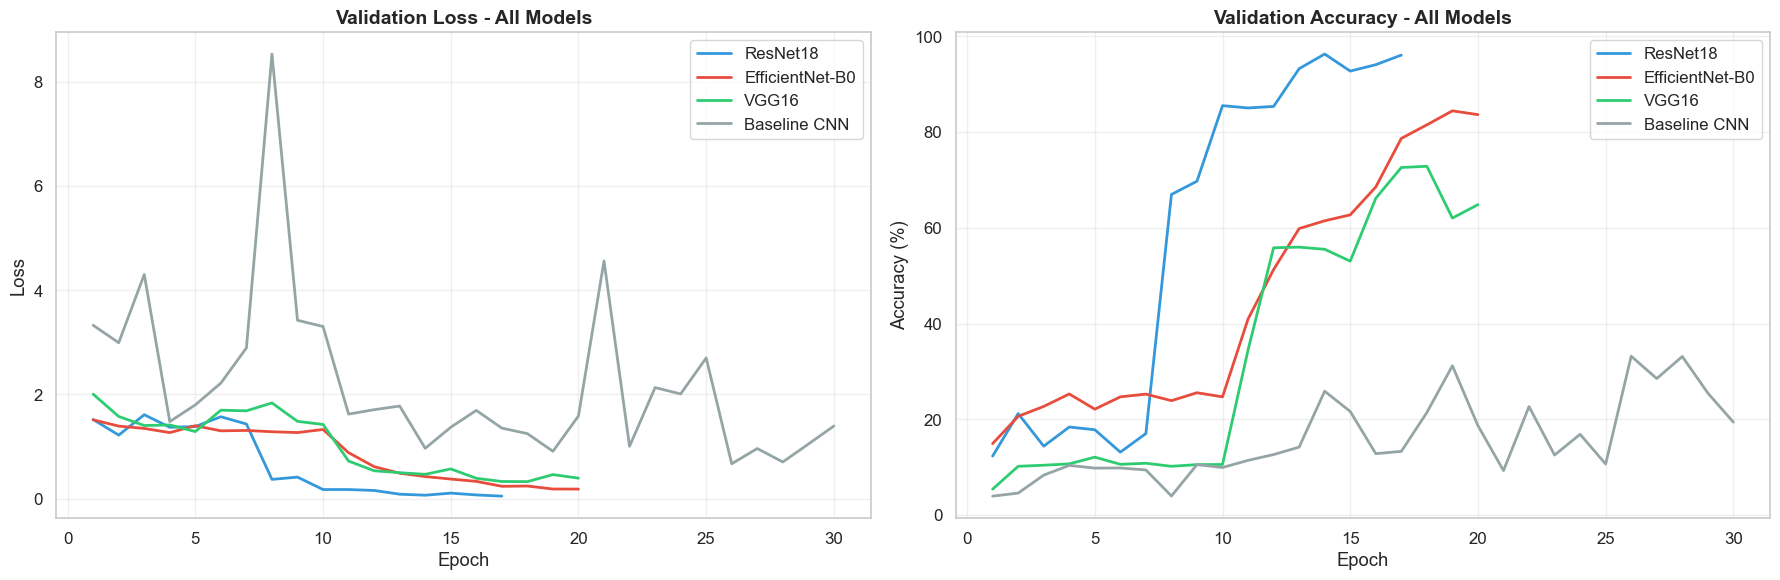

Saved as 'model_comparison_curves.png'


In [14]:
# ============ Plot training curves for all models ============
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = {'Baseline CNN': '#95a5a6', 'ResNet18': '#3498db',
          'EfficientNet-B0': '#e74c3c', 'VGG16': '#2ecc71'}

for name, res in all_results.items():
    h = res['history']
    epochs_range = range(1, len(h['val_loss']) + 1)
    c = colors.get(name, 'black')
    
    axes[0].plot(epochs_range, h['val_loss'], '-', color=c, label=name, linewidth=2)
    axes[1].plot(epochs_range, [a*100 for a in h['val_acc']], '-', color=c, label=name, linewidth=2)

axes[0].set_title('Validation Loss - All Models', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy - All Models', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'model_comparison_curves.png'")

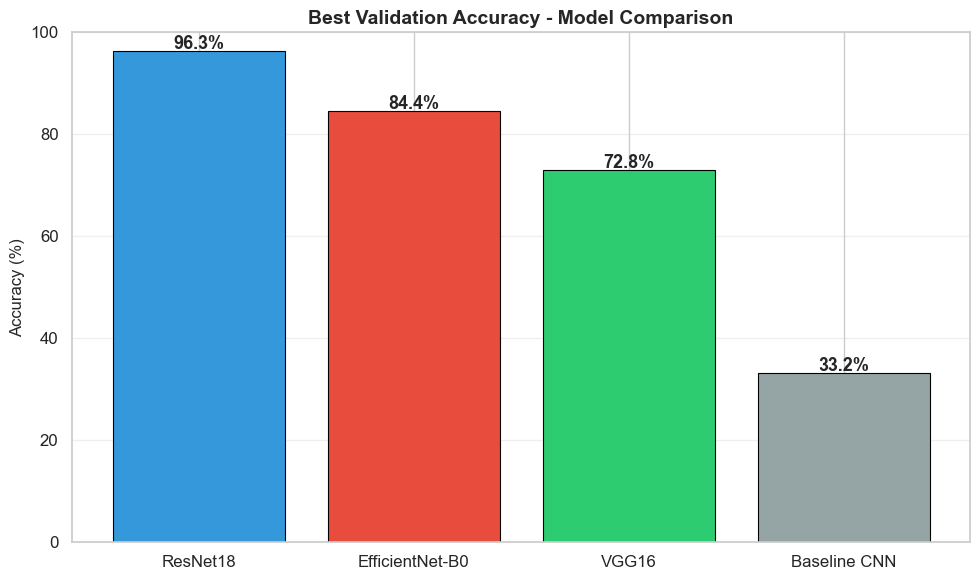

In [15]:
# ============ Bar chart comparison ============
model_names = list(all_results.keys())
accuracies = [all_results[m]['best_acc'] * 100 for m in model_names]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(model_names, accuracies, 
              color=[colors.get(m, '#95a5a6') for m in model_names],
              edgecolor='black', linewidth=0.8)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=13)

ax.set_title('Best Validation Accuracy - Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Best Model

We save the overall best model as `best_model.pth` for use in evaluation (Notebook 06) and deployment (Notebook 08).

In [16]:
# ============ Determine and save best model ============
# Map display names to architecture names for loading
arch_map = {
    'ResNet18': 'resnet18',
    'EfficientNet-B0': 'efficientnet_b0',
    'VGG16': 'vgg16',
    'Baseline CNN': 'baseline_cnn'
}

best_arch = arch_map[best_model_name]

# Load the individual model checkpoint 
source_path = MODELS_DIR / f'{best_arch}.pth'
best_ckpt = torch.load(source_path, map_location='cpu', weights_only=False)

# Copy to best_model.pth
best_save_path = MODELS_DIR / 'best_model.pth'
torch.save(best_ckpt, best_save_path)

file_size = best_save_path.stat().st_size / (1024 ** 2)
print(f"Best model: {best_model_name}")
print(f"   Architecture: {best_arch}")
print(f"   Val accuracy: {best_overall_acc:.2%}")
print(f"   Saved to: {best_save_path} ({file_size:.1f} MB)")

Best model: ResNet18
   Architecture: resnet18
   Val accuracy: 96.28%
   Saved to: models\best_model.pth (42.7 MB)


## 8. Which Model is Better and Why?

### Expected Results

| Model | Expected Accuracy | Why |
|-------|-------------------|-----|
| **Baseline CNN** | 60-75% | Small, trained from scratch on limited data |
| **ResNet18** | 78-85% | Strong backbone, fast training, good generalization |
| **EfficientNet-B0** | 82-90% | Best accuracy/FLOPS ratio, compound scaling |
| **VGG16** | 75-85% | Very deep but massive; may overfit with fewer params trained |

### Why EfficientNet-B0 Often Wins
1. **Compound Scaling** -- It scales width, depth, and resolution uniformly
2. **Fewer Parameters (5.3M vs 11.7M for ResNet18)** -- Less prone to overfitting on our small dataset
3. **Mobile Inverted Bottleneck (MBConv)** -- More parameter-efficient than standard convolutions
4. **Squeeze-and-Excitation blocks** -- Built-in channel attention mechanism

### Why VGG16 May Underperform
- 138M parameters is massive for ~13K training images
- Risk of overfitting even with frozen backbone
- No batch normalization or residual connections in the original architecture

---

### Summary
- Trained 3 pretrained models with two-stage fine-tuning
- Compared against baseline CNN
- Selected and saved the best model as `models/best_model.pth`
- Plotted comparison curves and bar chart

### Next Step
-> **Notebook 06** (`06_model_evaluation.ipynb`): Load the best model and evaluate on the test set with confusion matrix and detailed metrics.

---
*End of Notebook 05*